<a href="https://colab.research.google.com/github/Springboard429/B12---PlantDocBot-AI-Plant-Disease-Diagnosis-via-Chat-and-Image-Upload/blob/Sneha_John/plantdoc_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Unzip Dataset
This cell unzips the `archive.zip` file into the `/content/dataset` directory. It first ensures the extraction directory exists.

In [ ]:
import zipfile
import os

zip_path = '/content/archive.zip'
extract_path = '/content/dataset'

# Create folder if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipping completed successfully!")

Unzipping completed successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Import Libraries
This cell imports all the necessary Python libraries for data processing, model building, and training, including `torch`, `torchvision`, `PIL`, and `collections`.

In [ ]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from PIL import Image
from collections import Counter
from torch.nn import CrossEntropyLoss
import torch.nn as nn

### Define Validation Data Transformations
This cell defines the image transformations to be applied to the validation dataset. These transformations include resizing, conversion to tensor, and normalization, without any data augmentation specific to training.

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])])

In [ ]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])])

### Load Training Dataset
This cell loads the training image dataset from the specified root directory using `ImageFolder` and applies the defined `train_transform`. It also prints information about the loaded dataset, such as the number of classes and samples.

In [ ]:
train_data_root = '/content/dataset/PlantVillage/train'
train_dataset = datasets.ImageFolder(
    root=train_data_root,
    transform=train_transform
)
print(f"Train dataset loaded from: {train_data_root}")
print(f"Classes: {len(train_dataset.classes)}")
print(f"Samples: {len(train_dataset)}")
print(f"Class-to-index: {train_dataset.class_to_idx}")

Train dataset loaded from: /content/dataset/PlantVillage/train
Classes: 38
Samples: 43444
Class-to-index: {'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___hea

### Load Validation Dataset
This cell loads the validation image dataset from its specified root directory using `ImageFolder` and applies the defined `val_transform`. It also prints information about the loaded dataset.

In [ ]:
val_data_root = '/content/dataset/PlantVillage/val'
val_dataset = datasets.ImageFolder(
    root=val_data_root,
    transform=val_transform
)
print(f"Val dataset loaded from:{val_data_root}")
print(f"Classes: {len(val_dataset.classes)}")
print(f"Samples: {len(val_dataset)}")
print(f"Class-to-index: {val_dataset.class_to_idx}")

Val dataset loaded from:/content/dataset/PlantVillage/val
Classes: 38
Samples: 10861
Class-to-index: {'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy'

### Create Training DataLoader
This cell creates a DataLoader for the training dataset. It specifies the batch size, shuffles the data for better training, and uses multiple workers for efficient data loading.

In [ ]:
BATCH_SIZE = 32
NUM_WORKERS = 2

# Train DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)
print(f"Train loader:{len(train_loader)} batches")


Train loader:1358 batches


### Create Validation DataLoader
This cell creates a DataLoader for the validation dataset. It uses the specified batch size and does not shuffle the data, as shuffling is not necessary for validation.

In [ ]:
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)
print(f"Val loader:{len(val_loader)} batches")

Val loader:340 batches


### Calculate Class Weights and Define Loss Function
This cell calculates class weights to address potential class imbalance in the training dataset and then defines the `CrossEntropyLoss` function, incorporating these weights.

In [ ]:
# Extract labels from training dataset
train_labels = [label for _, label in train_dataset]
# Count samples per class
class_counts = Counter(train_labels)
# Total samples
total_samples = sum(class_counts.values())
# Compute class weights
class_weights = [
    total_samples / (len(class_counts) * class_counts[i])
    for i in range(len(class_counts))
]
class_weights = torch.tensor(class_weights, dtype=torch.float)
print("Class weights:", class_weights)

# Device configuration (added to resolve NameError)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Loss function with class weights
criterion = CrossEntropyLoss(weight=class_weights.to(device))

Class weights: tensor([2.2684, 2.3050, 5.1967, 0.8687, 0.9511, 1.3578, 1.6714, 2.7884, 1.1996,
        1.4508, 1.2306, 1.2111, 1.0328, 1.3278, 3.3725, 0.2595, 0.6220, 3.9697,
        1.4345, 0.9664, 1.4291, 1.4291, 9.4485, 3.8494, 0.2808, 0.7788, 1.2889,
        3.1408, 0.6717, 1.4291, 0.7487, 1.5023, 0.8068, 0.8525, 1.0180, 0.2667,
        3.8236, 0.8981])


### Verify Data Pipeline
This cell retrieves a batch of images and labels from both the training and validation DataLoaders to verify that the data pipeline is working correctly. It prints the shape, data type, and value range of the images.

In [ ]:
train_batch_images, train_batch_labels = next(iter(train_loader))
val_batch_images, val_batch_labels = next(iter(val_loader))

print("TRAIN BATCH:")
print(f" Images shape: {train_batch_images.shape}")
print(f" Labels shape: {train_batch_labels.shape}")
print(f" Images dtype: {train_batch_images.dtype}")
print(f" Value range: [{train_batch_images.min():.3f}, {train_batch_images.max():.3f}]")

print("\nVAL BATCH:")
print(f" Images shape: {val_batch_images.shape}")
print(f" Labels shape: {val_batch_labels.shape}")
print(f" Images dtype: {val_batch_images.dtype}")
print(f" Value range: [{val_batch_images.min():.3f}, {val_batch_images.max():.3f}]")

print("\nPipeline working correctly!"
      if train_batch_images.shape[0] == BATCH_SIZE else "Check pipeline")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TRAIN BATCH:
 Images shape: torch.Size([32, 3, 224, 224])
 Labels shape: torch.Size([32])
 Images dtype: torch.float32
 Value range: [-2.118, 2.640]

VAL BATCH:
 Images shape: torch.Size([32, 3, 224, 224])
 Labels shape: torch.Size([32])
 Images dtype: torch.float32
 Value range: [-2.101, 2.640]

Pipeline working correctly!


### Import Libraries for Model Training
This cell imports additional libraries required for model training, including `torch.optim` for optimizers, `tqdm` for progress bars, and `torchsummary` for model summaries.

In [ ]:
import torch.optim as optim
from tqdm import tqdm
import torch.nn as nn
from torchsummary import summary
import torch
from torch.utils.data import DataLoader

### Define and Summarize MLP Model
This cell defines a simple Multi-Layer Perceptron (MLP) neural network, initializes it, and prints a summary of its architecture and parameters using `torchsummary`.

In [ ]:
import torch
import torch.nn as nn
from torchsummary import summary

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# MLP Model
class SampleNN(nn.Module):
    def __init__(self, input_size, hidden_units, num_classes):
        super(SampleNN, self).__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, hidden_units),
            nn.ReLU(),
            nn.Linear(hidden_units, num_classes)
        )

    def forward(self, x):
        return self.model(x)

# Input configuration
input_size = 224 * 224 * 3
hidden_units = 128
num_classes = 38  # change based on your dataset classes

# Create model
mlp_model = SampleNN(
    input_size=input_size,
    hidden_units=hidden_units,
    num_classes=num_classes
).to(device)

# Print model summary
summary(mlp_model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1               [-1, 150528]               0
            Linear-2                  [-1, 128]      19,267,712
              ReLU-3                  [-1, 128]               0
            Linear-4                   [-1, 38]           4,902
Total params: 19,272,614
Trainable params: 19,272,614
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.57
Forward/backward pass size (MB): 1.15
Params size (MB): 73.52
Estimated Total Size (MB): 75.24
----------------------------------------------------------------


### Define MLP Optimizer and Scheduler
This cell sets up the Adam optimizer and a `StepLR` learning rate scheduler for the MLP model. The scheduler reduces the learning rate by a factor of 0.1 every 10 epochs.

In [ ]:
mlp_learning_rate = 0.001

mlp_optimizer = optim.Adam(mlp_model.parameters(), lr=mlp_learning_rate)

mlp_scheduler = optim.lr_scheduler.StepLR(
    mlp_optimizer,
    step_size=10,
    gamma=0.1
)

print(f"MLP Optimizer: Adam(lr={mlp_learning_rate})")
print("MLP Scheduler: StepLR (reduces LR by gamma after step_size epochs)")

MLP Optimizer: Adam(lr=0.001)
MLP Scheduler: StepLR (reduces LR by gamma after step_size epochs)


### Define Training Function
This cell defines the `train_one_epoch` function, which handles the training process for a single epoch. It iterates through the training data, performs forward and backward passes, and updates model weights.

In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

### Define Validation Function
This cell defines the `validate_one_epoch` function, which evaluates the model's performance on the validation set after each training epoch without updating weights.

In [ ]:
def validate_one_epoch(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

### Train MLP Model
This cell orchestrates the training and validation loop for the MLP model over a specified number of epochs. It calls the `train_one_epoch` and `validate_one_epoch` functions and steps the learning rate scheduler.

In [ ]:
num_epochs = 15

mlp_train_losses = []
mlp_val_losses = []
mlp_train_accs = []
mlp_val_accs = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        mlp_model, train_loader, criterion, mlp_optimizer, device
    )

    val_loss, val_acc = validate_one_epoch(
        mlp_model, val_loader, criterion, device
    )

    mlp_scheduler.step()

    mlp_train_losses.append(train_loss)
    mlp_val_losses.append(val_loss)
    mlp_train_accs.append(train_acc)
    mlp_val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f}")
    print("-"*50)

Validation: 100%|██████████| 340/340 [00:30<00:00, 10.99it/s]


Epoch [1/15]
Train Loss: 4.7853, Train Acc: 0.1086
Val Loss:   8.1408, Val Acc:   0.2006
--------------------------------------------------


Validation: 100%|██████████| 340/340 [00:31<00:00, 10.74it/s]


Epoch [2/15]
Train Loss: 3.8312, Train Acc: 0.1603
Val Loss:   6.1780, Val Acc:   0.2102
--------------------------------------------------


Validation: 100%|██████████| 340/340 [00:30<00:00, 11.02it/s]


...

Epoch [13/15]
Train Loss: 2.9015, Train Acc: 0.2437
Val Loss:   4.2555, Val Acc:   0.2446
--------------------------------------------------


Validation: 100%|██████████| 340/340 [00:30<00:00, 11.01it/s]


Epoch [14/15]
Train Loss: 2.8829, Train Acc: 0.2488
Val Loss:   4.2096, Val Acc:   0.2407
--------------------------------------------------


Validation: 100%|██████████| 340/340 [00:31<00:00, 10.86it/s]

Epoch [15/15]
Train Loss: 2.8472, Train Acc: 0.2538
Val Loss:   3.9847, Val Acc:   0.2397
--------------------------------------------------


### Plot MLP Loss and Accuracy
This cell uses `matplotlib` to plot the training and validation loss and accuracy curves for the MLP model across all epochs, providing a visual overview of its performance.

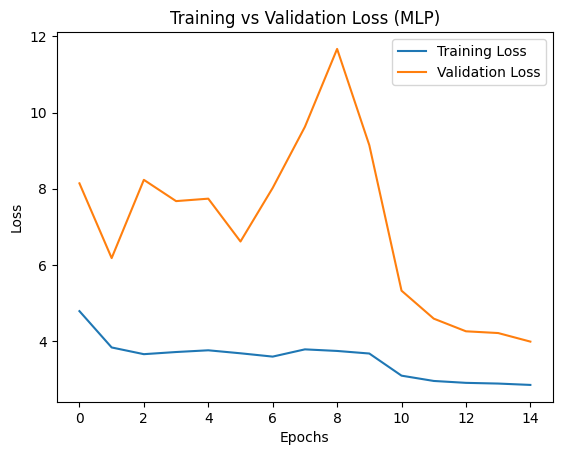

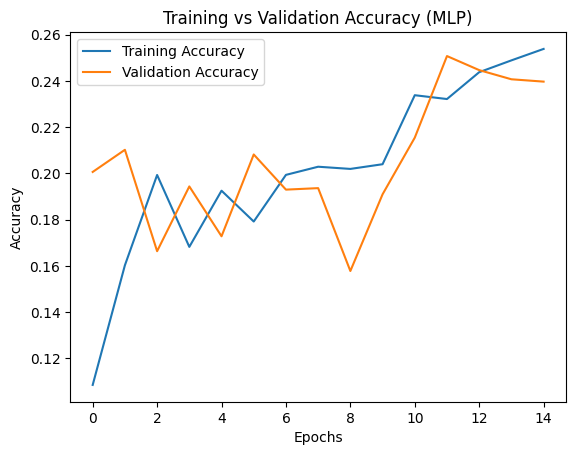

In [ ]:
import matplotlib.pyplot as plt

# Loss Curve
plt.figure()
plt.plot(mlp_train_losses, label='Training Loss')
plt.plot(mlp_val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss (MLP)')
plt.show()

# Add a newline for better separation in output
print("\n")

# Accuracy Curve
plt.figure()
plt.plot(mlp_train_accs, label='Training Accuracy')
plt.plot(mlp_val_accs, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy (MLP)')
plt.show()

### Print Final MLP Accuracy
This cell prints the final training and validation accuracies achieved by the MLP model after completing all training epochs.

In [ ]:
print(f"MLP Final Training Accuracy: {mlp_train_accs[-1]*100:.2f}%")
print(f"MLP Final Validation Accuracy: {mlp_val_accs[-1]*100:.2f}%")

MLP Final Training Accuracy: 25.38%
MLP Final Validation Accuracy: 23.97%


### Define and Summarize CNN Model
This cell defines a `SimpleCNN` model with convolutional layers, batch normalization, ReLU activations, and max-pooling layers, followed by a classifier. It then prints a summary of the CNN architecture.

In [ ]:
import torch
import torch.nn as nn
from torchsummary import summary

# CNN Model
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=38):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model initialization (IMPORTANT: 38 classes)
model = SimpleCNN(num_classes=38).to(device)

# Summary
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
       BatchNorm2d-2         [-1, 32, 224, 224]              64
              ReLU-3         [-1, 32, 224, 224]               0
         MaxPool2d-4         [-1, 32, 112, 112]               0
            Conv2d-5         [-1, 64, 112, 112]          18,496
       BatchNorm2d-6         [-1, 64, 112, 112]             128
              ReLU-7         [-1, 64, 112, 112]               0
         MaxPool2d-8           [-1, 64, 56, 56]               0
            Conv2d-9          [-1, 128, 56, 56]          73,856
      BatchNorm2d-10          [-1, 128, 56, 56]             256
             ReLU-11          [-1, 128, 56, 56]               0
        MaxPool2d-12          [-1, 128, 28, 28]               0
          Flatten-13               [-1, 100352]               0
           Linear-14                  [

### Define CNN Optimizer and Scheduler
This cell sets up the Adam optimizer for the CNN model with a specific learning rate and weight decay. It also defines a `ReduceLROnPlateau` scheduler, which dynamically adjusts the learning rate based on validation loss.

In [ ]:
# Learning rate
learning_rate = 0.0001

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=1e-4
)

# Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

print(f"Optimizer: Adam(lr={learning_rate}, weight_decay=1e-4)")
print("Scheduler: ReduceLROnPlateau (reduces LR when validation loss plateaus)")

Optimizer: Adam(lr=0.0001, weight_decay=1e-4)
Scheduler: ReduceLROnPlateau (reduces LR when validation loss plateaus)


### Train CNN Model
This cell executes the training and validation loop for the CNN model over a specified number of epochs, utilizing the `train_one_epoch` and `validate_one_epoch` functions and adjusting the learning rate with the scheduler.

In [ ]:
num_epochs = 15

train_losses = []
train_accs = [] # Changed from train_accuracies
val_losses = []
val_accs = [] # Changed from val_accuracies

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )

    train_losses.append(train_loss)
    train_accs.append(train_acc) # Changed from train_accuracies
    val_losses.append(val_loss)
    val_accs.append(val_acc) # Changed from val_accuracies

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Scheduler step uses validation loss
    scheduler.step(val_loss)

print("Training complete!")

Epoch 1/15


Validation: 100%|██████████| 340/340 [00:32<00:00, 10.32it/s]


Train Loss: 3.2950, Train Acc: 0.1230
Val Loss: 2.3804, Val Acc: 0.3501
Epoch 2/15


Validation: 100%|██████████| 340/340 [00:32<00:00, 10.46it/s]


Train Loss: 2.8813, Train Acc: 0.1787
Val Loss: 2.0161, Val Acc: 0.4957
Epoch 3/15


...

Train Loss: 1.3015, Train Acc: 0.5798
Val Loss: 0.6215, Val Acc: 0.8188
Epoch 14/15


Validation: 100%|██████████| 340/340 [00:32<00:00, 10.49it/s]


Train Loss: 1.2313, Train Acc: 0.6033
Val Loss: 0.5835, Val Acc: 0.8315
Epoch 15/15


Validation: 100%|██████████| 340/340 [00:32<00:00, 10.52it/s]

Train Loss: 1.1693, Train Acc: 0.6252
Val Loss: 0.6165, Val Acc: 0.8067
Training complete!


### Plot CNN Loss and Accuracy
This cell generates plots of the training and validation loss and accuracy for the CNN model over the training epochs, using `matplotlib`.

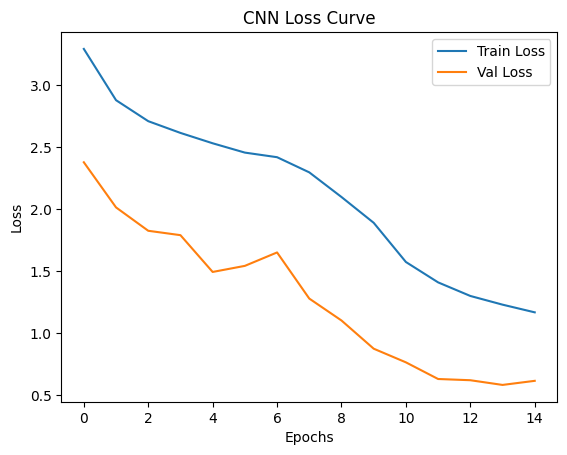

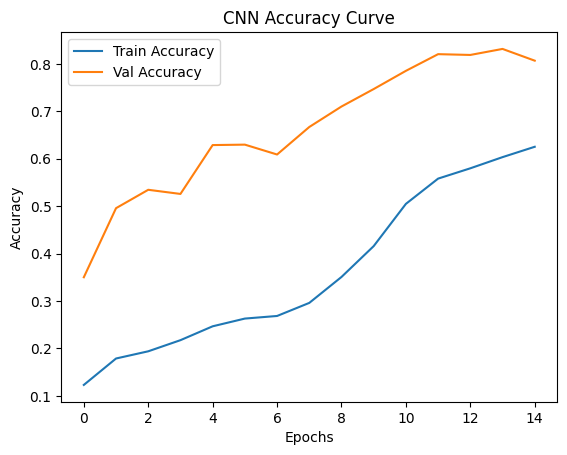

In [ ]:
import matplotlib.pyplot as plt

# Loss Curve
plt.figure()
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("CNN Loss Curve")
plt.show()
print("\n")
# Accuracy Curve
plt.figure()
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title("CNN Accuracy Curve")
plt.show()

In [ ]:
print(f"CNN Overall Accuracy: Train {train_accs[-1]*100:.2f}%, Val {val_accs[-1]*100:.2f}%")

CNN Overall Accuracy: Train 62.52%, Val 80.67%


Comparison

In [ ]:
print("MLP Training Accuracies per Epoch:")
print([f"{acc*100:.2f}%" for acc in mlp_train_accs])

print("\nCNN Training Accuracies per Epoch:")
print([f"{acc*100:.2f}%" for acc in train_accs])

MLP Training Accuracies per Epoch:
['10.86%', '16.03%', '19.93%', '16.82%', '19.25%', '17.92%', '19.94%', '20.29%', '20.19%', '20.40%', '23.38%', '23.21%', '24.37%', '24.88%', '25.38%']

CNN Training Accuracies per Epoch:
['12.30%', '17.87%', '19.39%', '21.74%', '24.66%', '26.29%', '26.84%', '29.60%', '35.07%', '41.57%', '50.48%', '55.81%', '57.98%', '60.33%', '62.52%']


### Final Performance Comparison
This cell prints a formatted table comparing the final training loss, training accuracy, validation loss, and validation accuracy for both the MLP and CNN models.

In [ ]:
print("\n====== FINAL PERFORMANCE COMPARISON ======")
print("{:<10} {:<12} {:<12} {:<12} {:<12}".format(
    "Model", "Train Loss", "Train Acc", "Val Loss", "Val Acc"
))

print("{:<10} {:<12.4f} {:<12.4f} {:<12.4f} {:<12.4f}".format(
    "MLP",
    mlp_train_losses[-1],
    mlp_train_accs[-1],
    mlp_val_losses[-1],
    mlp_val_accs[-1]
))

print("{:<10} {:<12.4f} {:<12.4f} {:<12.4f} {:<12.4f}".format(
    "CNN",
    train_losses[-1],
    train_accs[-1],
    val_losses[-1],
    val_accs[-1]
))



====== FINAL PERFORMANCE COMPARISON ======
Model      Train Loss   Train Acc    Val Loss     Val Acc     
MLP        2.8472       0.2538       3.9847       0.2397      
CNN        1.1693       0.6252       0.6165       0.8067      


### Plot Combined Loss and Accuracy
This cell creates combined plots showing the training and validation loss and accuracy for both the MLP and CNN models on the same graph, facilitating a visual comparison of their overall performance.

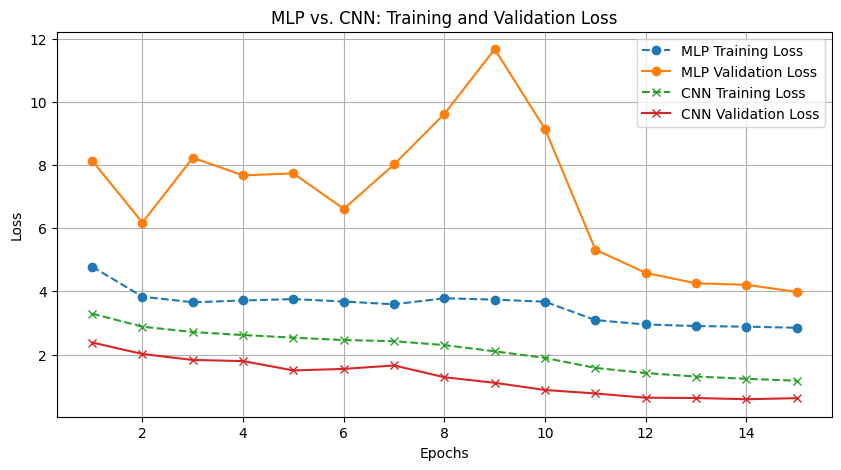

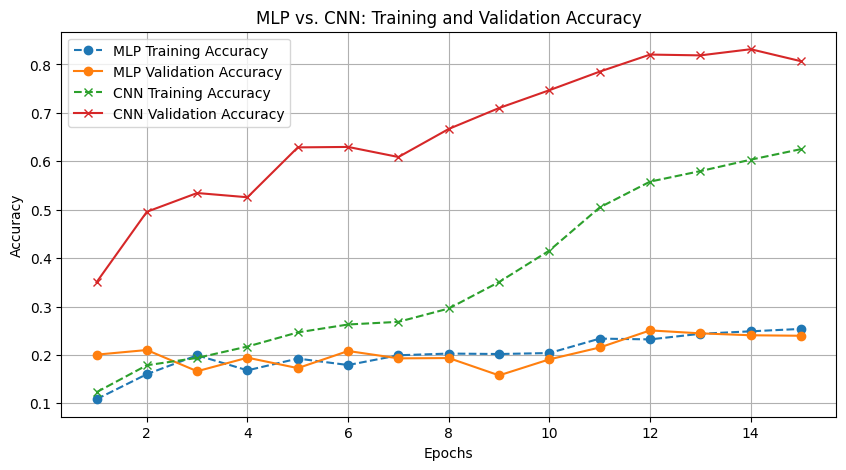

In [ ]:
import matplotlib.pyplot as plt

# Get the actual number of epochs for MLP and CNN from their respective lists
epochs_mlp = range(1, len(mlp_train_losses) + 1)
epochs_cnn = range(1, len(train_losses) + 1)

# Combined Loss Plot
plt.figure(figsize=(10, 5))
plt.plot(epochs_mlp, mlp_train_losses, label='MLP Training Loss', linestyle='--', marker='o')
plt.plot(epochs_mlp, mlp_val_losses, label='MLP Validation Loss', linestyle='-', marker='o')
plt.plot(epochs_cnn, train_losses, label='CNN Training Loss', linestyle='--', marker='x')
plt.plot(epochs_cnn, val_losses, label='CNN Validation Loss', linestyle='-', marker='x')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('MLP vs. CNN: Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Combined Accuracy Plot
plt.figure(figsize=(10, 5))
plt.plot(epochs_mlp, mlp_train_accs, label='MLP Training Accuracy', linestyle='--', marker='o')
plt.plot(epochs_mlp, mlp_val_accs, label='MLP Validation Accuracy', linestyle='-', marker='o')
plt.plot(epochs_cnn, train_accs, label='CNN Training Accuracy', linestyle='--', marker='x')
plt.plot(epochs_cnn, val_accs, label='CNN Validation Accuracy', linestyle='-', marker='x')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('MLP vs. CNN: Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### Predictions with CNN Model
This cell uses the trained CNN model (`model`) to make predictions on the `sample_images` obtained from the validation set. It moves images to the device, sets the model to evaluation mode, performs a forward pass, and extracts predicted labels.

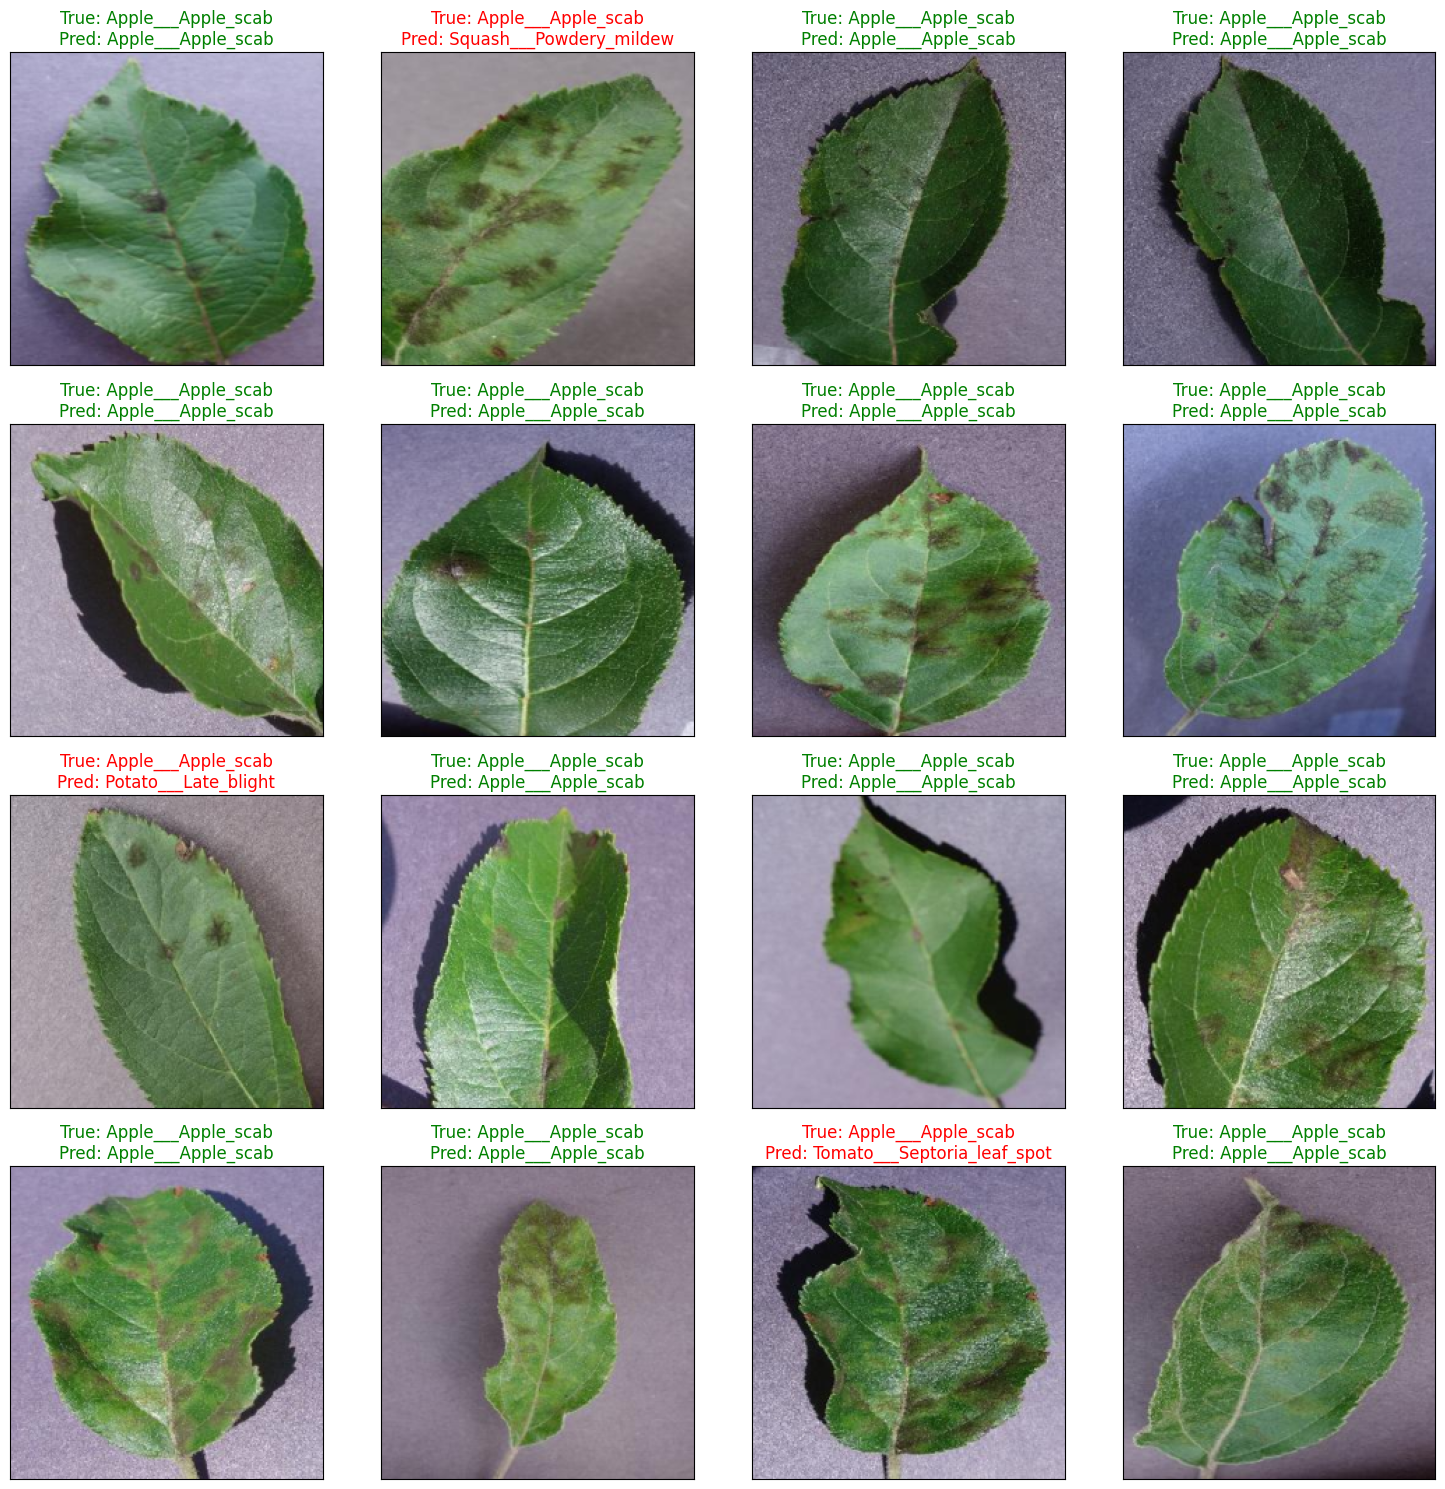

In [ ]:
import numpy as np
def visualize_val_samples(model, val_loader, class_names, device, num_images=16):
    model.eval()
    images, labels = next(iter(val_loader))
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

    fig = plt.figure(figsize=(15, 15))

    for i in range(num_images):
        ax = fig.add_subplot(4, 4, i + 1, xticks=[], yticks=[])

        img = images[i].cpu().numpy().transpose((1, 2, 0))

        # Denormalize
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        true_label = class_names[labels[i]]
        predicted_label = class_names[preds[i]]

        plt.imshow(img)
        plt.title(f"True: {true_label}\nPred: {predicted_label}")

        if true_label == predicted_label:
            ax.title.set_color("green")
        else:
            ax.title.set_color("red")

    plt.tight_layout()
    plt.show()
class_names = val_dataset.classes
visualize_val_samples(model, val_loader, class_names, device)

Save Model

In [ ]:
model_save_path = "/content/drive/MyDrive/best_simplecnn_plant_disease.pth"
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': class_names,
    'num_classes': len(class_names),
    'input_size': (3, 224, 224)
}, model_save_path)

print("Model saved successfully to Google Drive.")

Model saved successfully to Google Drive.


### Load Saved Model
This cell loads the previously saved CNN model from the `.pth` file, re-instantiating the `SimpleCNN` architecture and loading the saved weights into it. The model is then set to evaluation mode.

In [ ]:
model_path = "/content/drive/MyDrive/best_simplecnn_plant_disease.pth"

checkpoint = torch.load(model_path, map_location=torch.device('cpu'))

class_names = checkpoint['class_names']
num_classes = checkpoint['num_classes']

model = SimpleCNN(num_classes=num_classes)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device) # Move model to the correct device
model.eval()

print("Model loaded successfully.")

Model loaded successfully.


Image Transformer

In [ ]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

Prediction Function

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

def predict_image(image_path, actual_class_name):
    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)  # Move input tensor to the device

    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

    predicted_class = class_names[predicted.item()]
    confidence_score = confidence.item() * 100

    plt.imshow(image)
    plt.title(f"True: {actual_class_name}\nPred: {predicted_class}\nConfidence: {confidence_score:.2f}%")
    plt.axis("off")
    plt.show()

    return predicted_class, confidence_score

### Predict on Unseen Image
This cell demonstrates how to make a prediction on a single image using the `loaded_model`. It loads an image, applies the necessary transformations, and prints the predicted class name.

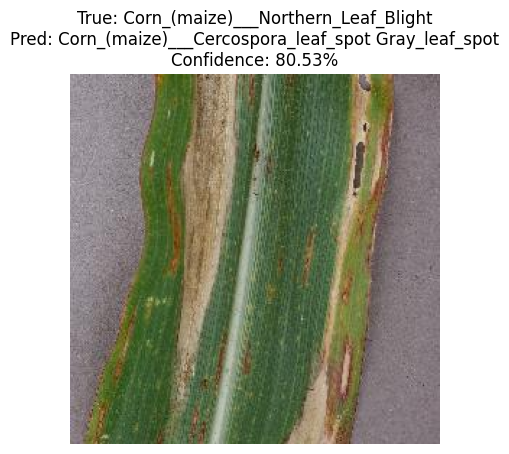

Actual Class: Corn_(maize)___Northern_Leaf_Blight
Predicted Class: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Confidence Score: 80.53%


In [ ]:
import matplotlib.pyplot as plt
import random

# Select a random image path and its true label from the validation dataset
random_index = random.randint(0, len(val_dataset.samples) - 1)
image_path_to_predict = val_dataset.samples[random_index][0]
true_label_index = val_dataset.samples[random_index][1]
true_class = class_names[true_label_index]

# Call the predict_image function to make a prediction and display the image
predicted_class, confidence_score = predict_image(image_path_to_predict, true_class);

# Print the results in the output area of the cell
print(f"Actual Class: {true_class}")
print(f"Predicted Class: {predicted_class}")
print(f"Confidence Score: {confidence_score:.2f}%")